# Punto 4 (1.2) — Transformación lineal a trozos

Nota: usa como entrada la imagen original en escala de grises. Asegúrate que las imágenes resultantes están en uint8 (rango 0-255).

In [1]:
# numpy: manejo de la imagen como matriz (arreglo N-dimensional) y toda la
#        indexación (recortes, reflexiones, reordenar canales).
# matplotlib.pyplot: mostrar y guardar (savefig) las imágenes resultantes.
# PIL.Image: leer archivos de imagen (.png/.tif) y convertir entre modos
#            de color (RGB, L = escala de grises).
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# sys.path.append("..") permite importar utils.py, que está un nivel arriba
# (en la raíz del proyecto), desde dentro de la carpeta notebooks/.
import sys
sys.path.append("..")
from utils import to_uint8, gamma_transform, log_transform, piecewise_linear, gray_level_slicing


## Imagen Original en Escala de Grises



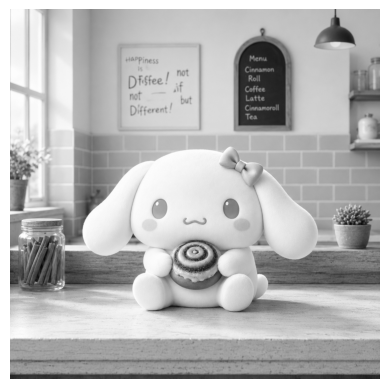

In [2]:
img = np.array(Image.open("../images/cinnamorroll_1024.png").convert("RGB"))
gray = np.array(Image.fromarray(img).convert("L"))

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_gris.png", bbox_inches="tight", pad_inches=0)


## T. Lineal a Trozos — r1=10 r2=50 s1=95 s2=145



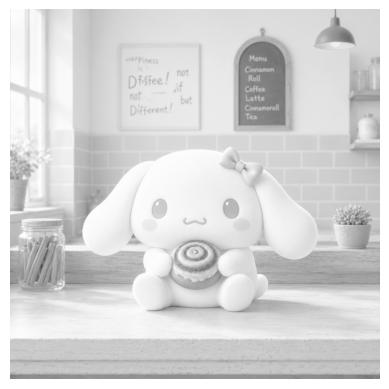

In [3]:
# piecewise_linear (utils.py) define una función a trozos con numpy:
# usa máscaras booleanas (gray <= r1, etc.) para aplicar una recta
# distinta en cada tramo, uniendo los puntos (0,0) -> (r1,s1) ->
# (r2,s2) -> (255,255). Aquí el rango de entrada 10-50 es bajo, y
# como pocos pixeles de la imagen caen ahí, el efecto se nota más
# en el tramo alto (>50), aclarando la imagen en general.
lineal_1 = piecewise_linear(gray, r1=10, s1=95, r2=50, s2=145)

plt.imshow(lineal_1, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_lineal_1.png", bbox_inches="tight", pad_inches=0)


## T. Lineal a Trozos — r1=60 r2=120 s1=95 s2=145



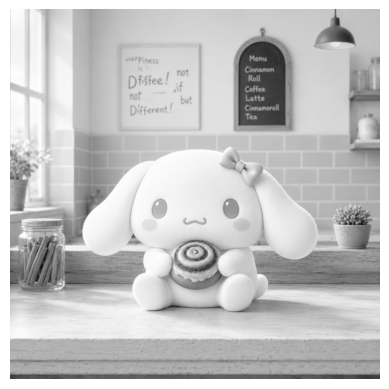

In [4]:
# Rango de entrada medio-bajo (60-120): cambio casi imperceptible en
# esta imagen porque pocos pixeles caen justo en ese rango.
lineal_2 = piecewise_linear(gray, r1=60, s1=95, r2=120, s2=145)

plt.imshow(lineal_2, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_lineal_2.png", bbox_inches="tight", pad_inches=0)


## T. Lineal a Trozos — r1=150 r2=200 s1=95 s2=145



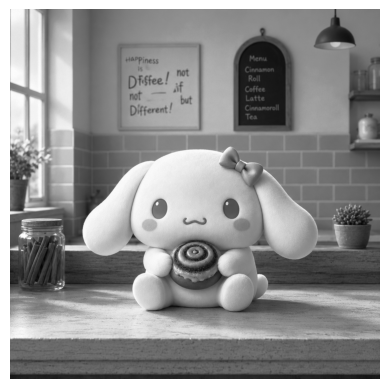

In [5]:
# Rango de entrada 150-200: coincide con donde se concentra buena
# parte del histograma de esta imagen (paredes claras, cuerpo del
# peluche), así que comprimirlo a 95-145 oscurece notablemente el
# resultado.
lineal_3 = piecewise_linear(gray, r1=150, s1=95, r2=200, s2=145)

plt.imshow(lineal_3, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_lineal_3.png", bbox_inches="tight", pad_inches=0)
